# Chaotic Data Recovery | Dataset Frankenstein

Este notebook crea archivos caoticos de prueba y demuestra como `DataRecoveryEngine` recupera la tabla principal sin detener la ejecucion.

Cobertura del stress test:
- Celdas combinadas en Excel.
- Titulos, separadores visuales y notas al pie.
- Fechas en formatos mixtos y multilingues.
- Montos con monedas, decimales y miles inconsistentes.
- Texto con mojibake intencional.
- CSV con encoding cp1252 y delimitador `;`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from openpyxl import Workbook

CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"c:\Users\yonai\Documents\Master Analytics and Visual in Big Data\Master\chaotic_data_recovery"),
]
PROJECT_ROOT = next(path for path in CANDIDATES if (path / "src" / "chaotic_data_recovery").exists())
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from chaotic_data_recovery import DataRecoveryEngine, RecoveryConfig

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
PROJECT_ROOT

WindowsPath('c:/Users/yonai/Documents/Master Analytics and Visual in Big Data/Master/chaotic_data_recovery')

In [2]:
def build_frankenstein_excel(path: Path) -> Path:
    workbook = Workbook()
    worksheet = workbook.active
    worksheet.title = "caos_regional"

    worksheet.merge_cells("A1:E1")
    worksheet["A1"] = "REPORTE COMERCIAL REGIONAL"
    worksheet.merge_cells("A2:B2")
    worksheet["A2"] = "Corte marzo 2026"
    worksheet["D2"] = "Documento interno"
    worksheet["A3"] = "-----------------------------------------"
    worksheet.append(["Cliente", "Fecha", "Monto", "Canal", "Notas"])
    worksheet.append(["JosÃ© Perez", "15 ene 2025", "€ 1.234,50", "Retail", "Pago en BogotÃ¡"])
    worksheet.append(["Marta Nunez", "03/07/2024", "USD 2,450.90", "Digital", "Cliente VIP"])
    worksheet.append(["Luis Gomez", "2024-11-05", "(3.000,00)", "Mayorista", "NC aplicada"])
    worksheet.append(["TOTAL", None, "$ 685,40", None, None])
    worksheet.append(["Nota legal: cifras preliminares sujetas a validacion", None, None, None, None])

    workbook.save(path)
    return path


def build_frankenstein_csv(path: Path) -> Path:
    rows = [
        "REPORTE EXPORTADO POR VENTAS - region norte;;;;",
        "No modificar manualmente | senal verde;;;;",
        "Cliente;Fecha;Monto;Moneda;Observacion",
        "Ana Peña;7 marzo 2025;€ 1.234,50;EUR;Cobro confirmado",
        "Carlos Ruiz;04/11/2024;USD 2,450.90;USD;Pago parcial",
        "Elena Díaz;ayer;EUR 3 520,10;EUR;Registro tardío",
        "TOTAL;;;;",
        "Pie: generado desde CRM legado versión 2;;;;",
    ]
    path.write_text("\n".join(rows) + "\n", encoding="cp1252", errors="replace")
    return path

In [3]:
excel_path = build_frankenstein_excel(RAW_DIR / "frankenstein_business_report.xlsx")
csv_path = build_frankenstein_csv(RAW_DIR / "frankenstein_sales_export.csv")

pd.DataFrame(
    {
        "artifact": ["excel", "csv"],
        "path": [str(excel_path), str(csv_path)],
    }
)

,artifact,path
0,excel,c:\Users\yonai\Documents\Master Analytics and Visual in Big Data\Master\chaotic_data_recovery\data\raw\frankenstein_...
1,csv,c:\Users\yonai\Documents\Master Analytics and Visual in Big Data\Master\chaotic_data_recovery\data\raw\frankenstein_...


## Ejecucion del motor con dos perfiles

Se prueba un Excel con celdas combinadas y mojibake, y un CSV con encoding cp1252, encabezados desplazados y pies de pagina.

In [4]:
excel_engine = DataRecoveryEngine(
    RecoveryConfig(
        footers_to_skip=1,
        decimal_separators=[",", "."],
        thousands_separators=[".", ",", " ", "'"],
        currency_symbols=["$", "€", "USD"],
        date_order="DMY",
    )
)
excel_result = excel_engine.run(excel_path)

display(excel_result.dataframe)
display(excel_result.report.library_usage_frame())
display(excel_result.report.garbage_rows_frame())
display(excel_result.report.column_health_frame())
excel_result.report.summary()

,cliente,fecha,monto,canal,notas
0,José Perez,2025-01-15,1234.5,Retail,Pago en Bogotá
1,Marta Nunez,2024-07-03,2450.9,Digital,Cliente VIP
2,Luis Gomez,2024-05-11,-3000.0,Mayorista,NC aplicada


,library,reason,details
0,openpyxl,Expanded merged Excel cells by propagating anchor values across each merged range.,"{'merged_ranges': 2, 'sheet': 'caos_regional'}"
1,ftfy,"Repaired mojibake, HTML entities, or broken punctuation in text fields.",{'repaired_values': 1}
2,dateparser,Parsed multilingual or ambiguous date strings into normalized timestamps.,"{'successful_values': 3, 'date_order': 'DMY'}"
3,numeric_normalizer,"Standardized mixed decimal, thousands, currency, and parenthesis-based numeric formats.",{'successful_values': 3}


,source_row_number,reason,preview
0,9,configured_footer_skip,Nota legal: cifras preliminares sujetas a validacion
1,1,preamble_or_title,REPORTE COMERCIAL REGIONAL | REPORTE COMERCIAL REGIONAL | REPORTE COMERCIAL REGIONAL | REPORTE COMERCIAL REGIONAL | ...
2,2,preamble_or_title,Corte marzo 2026 | Corte marzo 2026 | Documento interno
3,3,preamble_or_title,-----------------------------------------
4,8,subtotal_or_total_row,"TOTAL | $ 685,40"


,column_name,semantic_type,non_null_input,successful_standardizations,success_rate,notes
0,cliente,text,3,3,1.0,numeric_ratio=0.00; date_ratio=0.00
1,fecha,datetime,3,3,1.0,date_ratio=1.00; numeric_ratio=0.00
2,monto,numeric,3,3,1.0,numeric_ratio=1.00; date_ratio=0.00
3,canal,text,3,3,1.0,numeric_ratio=0.00; date_ratio=0.00
4,notas,text,3,3,1.0,numeric_ratio=0.00; date_ratio=0.00


{'source_path': 'c:\\Users\\yonai\\Documents\\Master Analytics and Visual in Big Data\\Master\\chaotic_data_recovery\\data\\raw\\frankenstein_business_report.xlsx',
 'source_type': 'excel',
 'encoding': None,
 'delimiter': None,
 'selected_sheet': 'caos_regional',
 'rows_in': 9,
 'rows_out': 3,
 'columns_out': 5,
 'libraries_fired': 4,
 'garbage_rows_logged': 5,
 'issues_logged': 0}

In [5]:
csv_engine = DataRecoveryEngine(
    RecoveryConfig(
        header_row=2,
        footers_to_skip=1,
        forced_encoding="cp1252",
        decimal_separators=[",", "."],
        thousands_separators=[".", ",", " ", "'"],
        currency_symbols=["$", "€", "USD", "EUR"],
        date_order="DMY",
    )
)
csv_result = csv_engine.run(csv_path)

display(csv_result.dataframe)
display(csv_result.report.library_usage_frame())
display(csv_result.report.garbage_rows_frame())
display(csv_result.report.column_health_frame())
csv_result.report.summary()

,cliente,fecha,monto,moneda,observacion
0,Ana Peña,2025-03-07,1234.5,EUR,Cobro confirmado
1,Carlos Ruiz,2024-11-04,2450.9,USD,Pago parcial
2,Elena Díaz,NaT,3520.1,EUR,Registro tardío


,library,reason,details
0,config_override,Used analyst-provided encoding override instead of byte-level inference.,{'encoding': 'cp1252'}
1,clevercsv,Detected CSV dialect from inconsistent row patterns and delimiters.,"{'delimiter': ';', 'quotechar': '', 'escapechar': ''}"
2,dateparser,Parsed multilingual or ambiguous date strings into normalized timestamps.,"{'successful_values': 2, 'date_order': 'DMY'}"
3,numeric_normalizer,"Standardized mixed decimal, thousands, currency, and parenthesis-based numeric formats.",{'successful_values': 3}


,source_row_number,reason,preview
0,8,configured_footer_skip,Pie: generado desde CRM legado versión 2
1,1,preamble_or_title,REPORTE EXPORTADO POR VENTAS - region norte
2,2,preamble_or_title,No modificar manualmente | senal verde
3,7,subtotal_or_total_row,TOTAL


,column_name,semantic_type,non_null_input,successful_standardizations,success_rate,notes
0,cliente,text,3,3,1.0000,numeric_ratio=0.00; date_ratio=0.00
1,fecha,datetime,3,2,0.6667,date_ratio=0.67; numeric_ratio=0.00
2,monto,numeric,3,3,1.0000,numeric_ratio=1.00; date_ratio=0.00
3,moneda,text,3,3,1.0000,numeric_ratio=0.00; date_ratio=0.00
4,observacion,text,3,3,1.0000,numeric_ratio=0.00; date_ratio=0.00


{'source_path': 'c:\\Users\\yonai\\Documents\\Master Analytics and Visual in Big Data\\Master\\chaotic_data_recovery\\data\\raw\\frankenstein_sales_export.csv',
 'source_type': 'text',
 'encoding': 'cp1252',
 'delimiter': ';',
 'selected_sheet': None,
 'rows_in': 8,
 'rows_out': 3,
 'columns_out': 5,
 'libraries_fired': 4,
 'garbage_rows_logged': 4,
 'issues_logged': 0}

,source,encoding,delimiter,rows_in,rows_out,libraries_fired,garbage_rows_logged
0,excel,None,None,9,3,4,5
1,csv,cp1252,;,8,3,4,4


,source,column_name,semantic_type,success_rate,notes
0,excel,cliente,text,1.0000,numeric_ratio=0.00; date_ratio=0.00
1,excel,fecha,datetime,1.0000,date_ratio=1.00; numeric_ratio=0.00
2,excel,monto,numeric,1.0000,numeric_ratio=1.00; date_ratio=0.00
3,excel,canal,text,1.0000,numeric_ratio=0.00; date_ratio=0.00
4,excel,notas,text,1.0000,numeric_ratio=0.00; date_ratio=0.00
5,csv,cliente,text,1.0000,numeric_ratio=0.00; date_ratio=0.00
6,csv,fecha,datetime,0.6667,date_ratio=0.67; numeric_ratio=0.00
7,csv,monto,numeric,1.0000,numeric_ratio=1.00; date_ratio=0.00
8,csv,moneda,text,1.0000,numeric_ratio=0.00; date_ratio=0.00
9,csv,observacion,text,1.0000,numeric_ratio=0.00; date_ratio=0.00


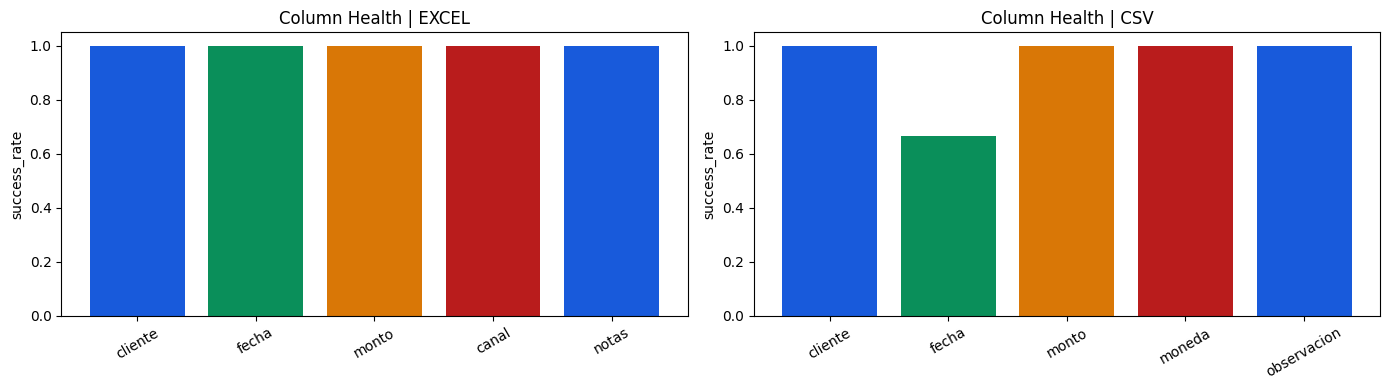

In [6]:
health_dashboard = pd.concat(
    [
        excel_result.report.column_health_frame().assign(source="excel"),
        csv_result.report.column_health_frame().assign(source="csv"),
    ],
    ignore_index=True,
)

summary_dashboard = pd.DataFrame([
    {"source": "excel", **excel_result.report.summary()},
    {"source": "csv", **csv_result.report.summary()},
])

display(summary_dashboard[["source", "encoding", "delimiter", "rows_in", "rows_out", "libraries_fired", "garbage_rows_logged"]])
display(health_dashboard[["source", "column_name", "semantic_type", "success_rate", "notes"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for axis, source_name in zip(axes, ["excel", "csv"]):
    subset = health_dashboard.loc[health_dashboard["source"] == source_name]
    axis.bar(subset["column_name"], subset["success_rate"], color=["#185adb", "#0a8f5a", "#d97706", "#b91c1c"][: len(subset)])
    axis.set_title(f"Column Health | {source_name.upper()}")
    axis.set_ylim(0, 1.05)
    axis.tick_params(axis="x", rotation=30)
    axis.set_ylabel("success_rate")
plt.tight_layout()
plt.show()

## Lectura operativa

El motor no se detiene ante celdas combinadas, filas ornamentales, totales ni formatos semanticos mezclados. El valor operativo esta en que devuelve tanto la tabla recuperada como el rastro auditable de que se descarto, que se reparo y que librerias especializadas participaron en la recuperacion.